In [1]:
from pathlib import Path
import os
import sys

import mne

project_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "pyproject.toml").exists()
)

os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

%matplotlib qt

Channels marked as bad:
none
Dropped 0 epochs: 
The following epochs were marked as bad and are dropped:
[]
Channels marked as bad:
none


In [2]:
from modules.decode_trigger import decode_8bit_trigger, convert_dict_trigger
from modules.events import get_events_tms_per_task

In [3]:
raw_data = mne.io.read_raw_bdf(r"data/raw/V1.bdf")

Extracting BDF parameters from data/raw/V1.bdf...
Setting channel info structure...
Creating raw.info structure...


In [4]:
emg_ch_names = ["EMG L", "EMG R"]
eog_ch_names = ["EOG"]
raw_data.set_channel_types({ch: "emg" for ch in emg_ch_names})
raw_data.set_channel_types({'EOG':'eog'})

montage = mne.channels.make_standard_montage("standard_1020",head_size='auto')
raw_data.set_montage(montage)

<RawBDF | V1.bdf, 67 x 12595000 (2519.0 s), ~79 KiB, data not loaded>

In [5]:
events, event_id = mne.events_from_annotations(raw_data)
event_id = raw_data.event_id = convert_dict_trigger(event_id, decode_8bit_trigger)

Used Annotations descriptions: [np.str_('8Bit 1'), np.str_('8Bit 10'), np.str_('8Bit 2'), np.str_('8Bit 3'), np.str_('8Bit 4'), np.str_('8Bit 5'), np.str_('Stimulus A')]


Using matplotlib as 2D backend.


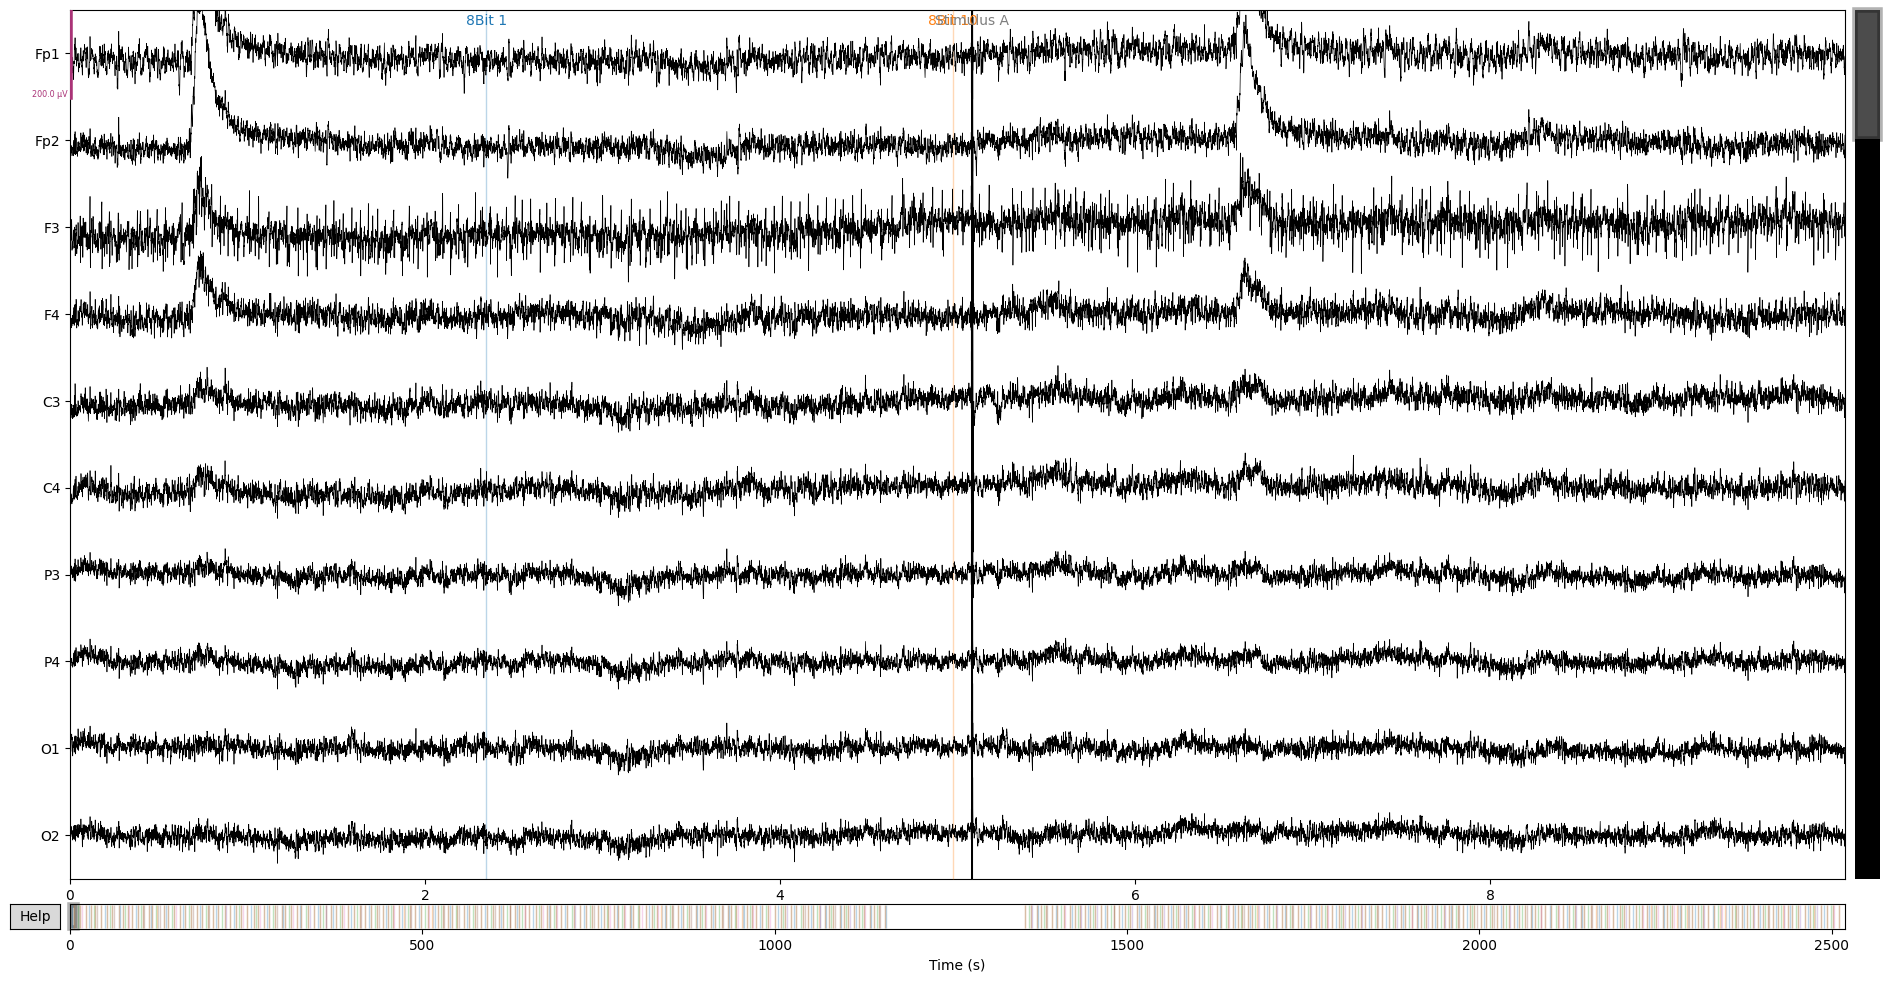

In [6]:
raw_data.plot(scalings={"eeg": 100e-6, "emg": 500e-6, "eog": 200e-6}, n_channels=10)

In [7]:
bad_ch =['F7', 'F5', 'P7', 'CPz', 'Oz', 'Iz', 'PO4', 'PO8', 'O2', "P6", "P8", "TP8", "C6", "TP10", "TP9", "F6", "FT8", "T8", "T7", "F3"]
raw_data.drop_channels(bad_ch)

<RawBDF | V1.bdf, 47 x 12595000 (2519.0 s), ~65 KiB, data not loaded>

In [ ]:
events_left, events_right, events_bilateral = get_events_tms_per_task(events, event_id)

In [17]:
epochs_left = mne.Epochs(
    raw_data,
    events_left,
    tmin=-0.8,
    tmax=0.8,
    baseline=(-0.25,-0.1),
    preload=True,
    detrend=1,
)

Not setting metadata
36 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Loading data for 36 events and 8001 original time points ...
0 bad epochs dropped
